# Lab 1 — Multiple linear regression and honest model selection

**Out week 2, due week 4.**

Two datasets, one question: *how do you find out how well your model will actually do?*

* **Part A — robot calibration.** Predict motor current from joint angles and strain
  gauges. You will fit the same model three ways and get three different answers about
  how good it is, only one of which is honest.
* **Part B — neural decoding.** Predict a monkey's hand velocity from cortical spike
  counts. You will choose a model order by cross-validation and the one-standard-error
  rule.

### Your seed
Set `SEED` to **the last four digits of your N-number** in the first code cell. Your
feature ablation in Part A and your neuron subsample in Part B both depend on it. Report
your seed at the top of your submission. **We regrade against it.**

### AI policy
Tools are allowed. Include an AI-use note at the end: which tools, on which parts, and
one sentence on something it got wrong. Two places in this lab are chosen because the
obvious code an assistant writes is wrong for *this* data — they are marked
**STOP AND THINK**. Answer those from your own output.

### What to submit
This notebook, run top to bottom, with every question answered in the markdown cell
that asks it. Prose answers are most of the grade. Code that runs but is not
interpreted scores about half.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, TimeSeriesSplit, train_test_split
from sklearn.metrics import r2_score

SEED = 4387          # <-- your last four N-number digits
rng = np.random.default_rng(SEED)
np.set_printoptions(precision=4, suppress=True)
print("seed", SEED)

seed 4387


---
# Part A — Robot calibration

Data from TU Dortmund's [MERIt dataset](https://www.rst.e-technik.tu-dortmund.de/)
(Multi-Elastic-Link Robot Identification): a three-link arm, 80 seconds of motion per
experiment, sampled every 10 ms. Two of the ten experiments are bundled with this lab:
`exp1.csv` (training) and `exp2.csv` (test).

We want to predict `I2`, the current drawn by the second joint's motor, from that
joint's angle, velocity, acceleration and the four strain gauges. Physically this is a
calibration problem: if you can predict the current a motion *will* draw, you can
detect a fault when the real current disagrees.

## A1. Load the data, carefully

The CSVs have **no header row**. Open `exp1.csv` in a text editor (or run the cell
below) and look at the first line before you write any `read_csv` call.

In [2]:
df = pd.read_csv("exp1.csv")


In [3]:
df.head()

,0,-6.7128e-06,2.4958,-1.1345,-7.8821e-21,-4.9407e-321,3.9131e-29,-0.081623,-0.40812,-0.30609,-269.25,-113.2,3.5918,1.5786,-9.9049e-19,-6.2103e-319,4.9174e-27
0,0.01,-0.000007,2.4958,-1.1345,-2.258200e-21,-4.940656e-321,2.626200e-31,-0.037411,-0.37241,-0.26698,-270.91,-116.05,1.4585,-1.73980,4.248100e-19,-1.766878e-319,-1.381100e-27
1,0.02,-0.000007,2.4958,-1.1345,-6.469800e-22,-4.940656e-321,1.762500e-33,-0.066319,-0.40302,-0.31459,-269.25,-112.97,3.5918,0.86753,3.233800e-19,-4.990557e-320,-4.117300e-28
2,0.03,-0.000007,2.4958,-1.1345,-1.853600e-22,-4.940656e-321,1.182800e-35,-0.068020,-0.43703,-0.28398,-269.97,-114.39,1.6956,-0.08059,1.500500e-19,-1.394253e-320,-1.173100e-28
3,0.04,-0.000007,2.4958,-1.1345,-5.310600e-23,-4.940656e-321,-5.270900e-03,-0.052715,-0.40472,-0.30779,-269.97,-114.15,3.1177,0.86753,5.932400e-20,-3.581976e-321,-3.770800e-01
4,0.05,-0.000007,2.4958,-1.1345,-1.521500e-23,-4.940656e-321,3.252600e-04,-0.088425,-0.42342,-0.29589,-269.25,-114.15,2.4066,-0.08059,2.164600e-20,-1.141292e-321,2.930300e-01


In [4]:
print(open("exp1.csv").readline())

0,-6.7128e-06,2.4958,-1.1345,-7.8821e-21,-4.9407e-321,3.9131e-29,-0.081623,-0.40812,-0.30609,-269.25,-113.2,3.5918,1.5786,-9.9049e-19,-6.2103e-319,4.9174e-27



In [5]:
wrong = pd.read_csv('exp1.csv')

print("Shape:", wrong.shape)
print("\nDtypes:")
print(wrong.dtypes)

print("\nAre all dtypes float?")
print(wrong.dtypes.apply(lambda x: x == 'float64').all())

Shape: (7999, 17)

Dtypes:
0               float64
-6.7128e-06     float64
2.4958          float64
-1.1345         float64
-7.8821e-21     float64
-4.9407e-321    float64
3.9131e-29      float64
-0.081623       float64
-0.40812        float64
-0.30609        float64
-269.25         float64
-113.2          float64
3.5918          float64
1.5786          float64
-9.9049e-19     float64
-6.2103e-319    float64
4.9174e-27      float64
dtype: object

Are all dtypes float?
True


Now load both files with the column names below, using time as the index.

**You must pass `header=None`.** Without it pandas silently consumes the first
data row as a header and you lose a sample and get object dtypes. Load it *wrongly*
first, print `df.shape` and `df.dtypes`, then load it correctly — you will meet this
bug again on data you did not get warned about.

In [6]:
names = [
    't',                                  # time (s)
    'q1', 'q2', 'q3',                     # joint angle (rad)
    'dq1', 'dq2', 'dq3',                  # joint velocity (rad/s)
    'I1', 'I2', 'I3',                     # motor current (A)
    'eps21', 'eps22', 'eps31', 'eps32',   # strain gauges (um/m)
    'ddq1', 'ddq2', 'ddq3',               # joint acceleration (rad/s^2)
]

df_tr = pd.read_csv(
    'exp1.csv',
    header=None,
    names=names
)

df_ts = pd.read_csv(
    'exp2.csv',
    header=None,
    names=names
)

df_tr = df_tr.set_index('t')
df_ts = df_ts.set_index('t')


# TODO
# 1. load exp1.csv WITHOUT header=None into `wrong`; print its shape and whether all dtypes are float
# 2. load exp1.csv and exp2.csv correctly (header=None) into df_tr and df_ts
# 3. print both shapes and display the first six rows of df_tr

In [7]:
print("Training shape:", df_tr.shape)
print("Test shape:", df_ts.shape)

display(df_tr.head(6))

Training shape: (8000, 16)
Test shape: (8000, 16)


,q1,q2,q3,dq1,dq2,dq3,I1,I2,I3,eps21,eps22,eps31,eps32,ddq1,ddq2,ddq3
t,,,,,,,,,,,,,,,,
0.00,-0.000007,2.4958,-1.1345,-7.882100e-21,-4.940656e-321,3.913100e-29,-0.081623,-0.40812,-0.30609,-269.25,-113.20,3.5918,1.57860,-9.904900e-19,-6.210306e-319,4.917400e-27
0.01,-0.000007,2.4958,-1.1345,-2.258200e-21,-4.940656e-321,2.626200e-31,-0.037411,-0.37241,-0.26698,-270.91,-116.05,1.4585,-1.73980,4.248100e-19,-1.766878e-319,-1.381100e-27
0.02,-0.000007,2.4958,-1.1345,-6.469800e-22,-4.940656e-321,1.762500e-33,-0.066319,-0.40302,-0.31459,-269.25,-112.97,3.5918,0.86753,3.233800e-19,-4.990557e-320,-4.117300e-28
0.03,-0.000007,2.4958,-1.1345,-1.853600e-22,-4.940656e-321,1.182800e-35,-0.068020,-0.43703,-0.28398,-269.97,-114.39,1.6956,-0.08059,1.500500e-19,-1.394253e-320,-1.173100e-28
0.04,-0.000007,2.4958,-1.1345,-5.310600e-23,-4.940656e-321,-5.270900e-03,-0.052715,-0.40472,-0.30779,-269.97,-114.15,3.1177,0.86753,5.932400e-20,-3.581976e-321,-3.770800e-01
0.05,-0.000007,2.4958,-1.1345,-1.521500e-23,-4.940656e-321,3.252600e-04,-0.088425,-0.42342,-0.29589,-269.25,-114.15,2.4066,-0.08059,2.164600e-20,-1.141292e-321,2.930300e-01


**Q A1.** How many rows did the wrong load produce, and what happened to the dtypes?
Write one sentence explaining *why* pandas did that.

###Answer A1 : The wrong load produced 7,999 rows instead of 8,000, and pandas interpreted the first data row as the header, so the column labels became the values from that first row. The remaining data were still read as floats, which is why all 17 columns show float64.

## A2. Look at the target before you model it

Extract time into `t` and the second-joint current into `y`. Plot `y` against `t` with
axis labels **and units**. Then plot only the first 3 seconds.

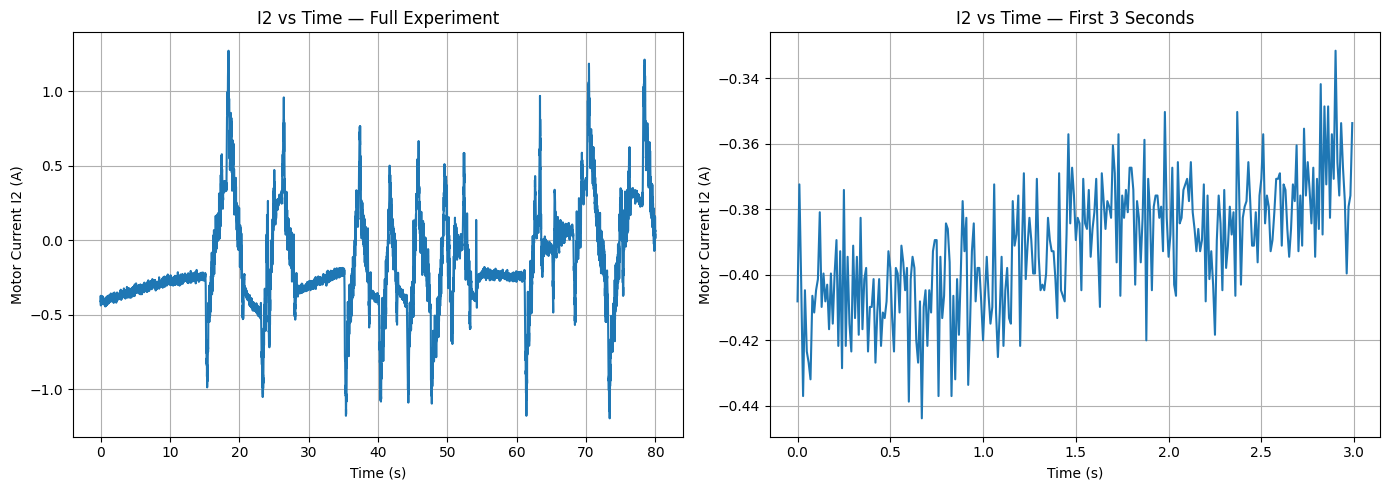

In [8]:
# TODO: t = the index, y = the I2 column.
# Left panel: y vs t for the whole experiment. Right panel: only t < 3 seconds.
# Label axes with units.

import matplotlib.pyplot as plt

# Time and target
t = df_tr.index.to_numpy()
y = df_tr['I2'].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full experiment
axes[0].plot(t, y)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Motor Current I2 (A)')
axes[0].set_title('I2 vs Time — Full Experiment')
axes[0].grid(True)

# First 3 seconds
mask = t < 3

axes[1].plot(t[mask], y[mask])
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Motor Current I2 (A)')
axes[1].set_title('I2 vs Time — First 3 Seconds')
axes[1].grid(True)

plt.tight_layout()
plt.show()

**Q A2.** Look at the 3-second plot. Are consecutive samples close to independent, or
does knowing $y$ at time $\tau$ tell you a lot about $y$ at $\tau + 0.01$ s?
One sentence. **Keep your answer in mind for A5 — it is the whole point of this part.**

###Answer A2: The consecutive samples are not independent. The current values fluctuate around a smooth local trend, so knowing \(y\) at time \(t\) provides substantial information about \(y\) at \(t+0.01\) s.

## A3. Fit it three ways and make them agree

Build the training matrices with predictors
`['q2','dq2','eps21','eps22','eps31','eps32','ddq2']` and target `I2`. Fit the linear
model three ways and check all three coefficient vectors match to $10^{-8}$:

1. normal equations solved with `np.linalg.solve` on $A^TA\,\beta = A^Ty$, where
   $A = [\mathbf 1 \;\; X]$
2. `np.linalg.lstsq(A, y, rcond=None)`
3. `sklearn.linear_model.LinearRegression`

Do **not** use `np.linalg.inv`. Explain in one line why `solve` is preferred.

In [9]:
xcols = ['q2', 'dq2', 'eps21', 'eps22', 'eps31', 'eps32', 'ddq2']
Xtr, ytr = df_tr[xcols].to_numpy(), df_tr['I2'].to_numpy()
Xts, yts = df_ts[xcols].to_numpy(), df_ts['I2'].to_numpy()
print(Xtr.shape, ytr.shape)

# TODO: build A = [1, Xtr]; get b_normal (np.linalg.solve), b_lstsq, b_sklearn.
# Build A = [1, Xtr]
A = np.column_stack([np.ones(Xtr.shape[0]), Xtr])

# 1. Normal equations using np.linalg.solve
b_normal = np.linalg.solve(A.T @ A, A.T @ ytr)

# 2. Least squares using np.linalg.lstsq
b_lstsq = np.linalg.lstsq(A, ytr, rcond=None)[0]

# 3. sklearn LinearRegression
model = LinearRegression()
model.fit(Xtr, ytr)

b_sklearn = np.concatenate([[model.intercept_], model.coef_])

# Print all three
print("b_normal:")
print(b_normal)

print("\nb_lstsq:")
print(b_lstsq)

print("\nb_sklearn:")
print(b_sklearn)

# Check agreement
print("\nMaximum absolute differences:")
print("normal vs lstsq   =", np.max(np.abs(b_normal - b_lstsq)))
print("normal vs sklearn =", np.max(np.abs(b_normal - b_sklearn)))
print("lstsq vs sklearn  =", np.max(np.abs(b_lstsq - b_sklearn)))

# Assert agreement to 1e-8
assert np.allclose(b_normal, b_lstsq, atol=1e-8)
assert np.allclose(b_normal, b_sklearn, atol=1e-8)

print("\nAll three coefficient vectors agree to 1e-8.")
# Print all three and assert they agree to 1e-8.

(8000, 7) (8000,)
b_normal:
[-0.0841  0.0626  0.2058  0.0012  0.0004 -0.0031  0.006   0.0549]

b_lstsq:
[-0.0841  0.0626  0.2058  0.0012  0.0004 -0.0031  0.006   0.0549]

b_sklearn:
[-0.0841  0.0626  0.2058  0.0012  0.0004 -0.0031  0.006   0.0549]

Maximum absolute differences:
normal vs lstsq   = 3.354261313148754e-14
normal vs sklearn = 7.802092305553288e-14
lstsq vs sklearn  = 5.1764148523147924e-14

All three coefficient vectors agree to 1e-8.


**Q A3.** Why `np.linalg.solve(A.T @ A, A.T @ y)` rather than
`np.linalg.inv(A.T @ A) @ A.T @ y`? One sentence about cost, one about conditioning.

### Answer A3: np.linalg.solve is preferred because it avoids explicitly computing a matrix inverse, making it more computationally efficient and numerically more stable.

## A4. Score it on experiment 2

Report $R^2$ on the training experiment and on experiment 2, and overlay predicted vs
actual current over time for the first 3 seconds of experiment 2.

Training R²: 0.9041673613876681
Experiment 2 R²: 0.8732195119523756


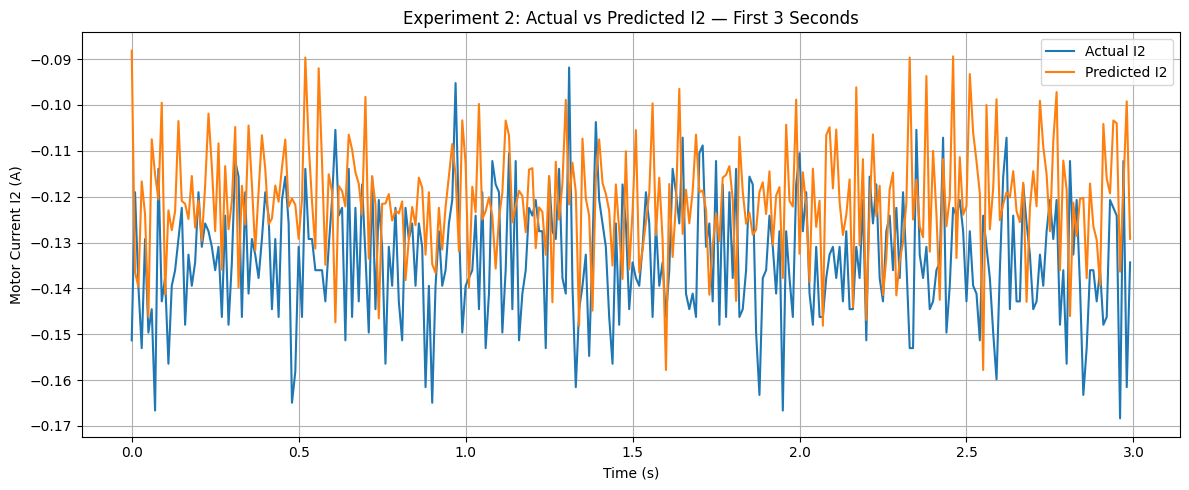

In [10]:
# TODO: print R2 on training and on exp2; overlay actual vs predicted for the
# first 3 seconds of experiment 2.

from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Predictions
ytr_pred = model.predict(Xtr)
yts_pred = model.predict(Xts)

# R² scores
r2_train = r2_score(ytr, ytr_pred)
r2_test = r2_score(yts, yts_pred)

print("Training R²:", r2_train)
print("Experiment 2 R²:", r2_test)

# Time for experiment 2
t_ts = df_ts.index.to_numpy()

# First 3 seconds
mask = t_ts < 3

# Overlay actual and predicted current
plt.figure(figsize=(12, 5))

plt.plot(t_ts[mask], yts[mask], label='Actual I2')
plt.plot(t_ts[mask], yts_pred[mask], label='Predicted I2')

plt.xlabel('Time (s)')
plt.ylabel('Motor Current I2 (A)')
plt.title('Experiment 2: Actual vs Predicted I2 — First 3 Seconds')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## A5. STOP AND THINK — three cross-validation schemes, three answers

You now want a cross-validated estimate of performance using **only experiment 1**,
because in a deployed system you would not have a second experiment lying around.

Run 5-fold CV on experiment 1 three ways and report the mean $R^2$ of each:

| scheme | what it does |
|---|---|
| `KFold(5, shuffle=True, random_state=SEED)` | random folds |
| `KFold(5, shuffle=False)` | five contiguous time blocks |
| `TimeSeriesSplit(5)` | expanding window, always predicts the future |

Then compare all three against the number you already know is honest: $R^2$ on
experiment 2.

**Predict, in the markdown cell below, which of the three will come closest to the
experiment-2 number — before you run the cell.** Writing the prediction down is part of
the grade.

**Q A5a (prediction, write before running).** Which scheme do you expect to match the
experiment-2 $R^2$ most closely, and why?

Answer A5a: I expect KFold(5, shuffle=False) to match the Experiment-2 \(R^2\) most closely because it preserves the temporal ordering of the data and evaluates the model on contiguous time blocks, making it more representative of predicting on a separate experiment than randomly mixing nearby, highly correlated samples.

In [11]:
# TODO: for each of the three CV schemes, fit on each training fold, score on the
# held-out fold, and print the mean R2 AND the individual fold scores.
# Then print the experiment-2 R2 again for comparison.

from sklearn.model_selection import KFold, TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# Define the three CV schemes
cv_shuffled = KFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

cv_block = KFold(
    n_splits=5,
    shuffle=False
)

cv_time = TimeSeriesSplit(
    n_splits=5
)


def run_cv(cv):
    fold_scores = []

    for train_idx, val_idx in cv.split(Xtr):

        # Training and validation data
        X_train = Xtr[train_idx]
        y_train = ytr[train_idx]

        X_val = Xtr[val_idx]
        y_val = ytr[val_idx]

        # Fit model
        model_cv = LinearRegression()
        model_cv.fit(X_train, y_train)

        # Predict validation fold
        y_pred = model_cv.predict(X_val)

        # R²
        score = r2_score(y_val, y_pred)
        fold_scores.append(score)

    fold_scores = np.array(fold_scores)

    return fold_scores.mean(), fold_scores


# 1. Shuffled KFold
mean_shuffled, scores_shuffled = run_cv(cv_shuffled)

# 2. Contiguous KFold
mean_block, scores_block = run_cv(cv_block)

# 3. TimeSeriesSplit
mean_time, scores_time = run_cv(cv_time)


# Print results
print("=== Shuffled KFold ===")
print("Individual fold R²:", scores_shuffled)
print("Mean R²:", mean_shuffled)

print("\n=== Contiguous KFold ===")
print("Individual fold R²:", scores_block)
print("Mean R²:", mean_block)

print("\n=== TimeSeriesSplit ===")
print("Individual fold R²:", scores_time)
print("Mean R²:", mean_time)

print("\n=== Experiment 2 ===")
print("Experiment 2 R²:", r2_test)

=== Shuffled KFold ===
Individual fold R²: [0.9026 0.898  0.9053 0.9092 0.9046]
Mean R²: 0.9039282131901013

=== Contiguous KFold ===
Individual fold R²: [0.4142 0.9108 0.8566 0.7415 0.9096]
Mean R²: 0.7665327922406209

=== TimeSeriesSplit ===
Individual fold R²: [-913.1821    0.6522    0.8768    0.6241    0.9112]
Mean R²: -182.02356345337714

=== Experiment 2 ===
Experiment 2 R²: 0.8732195119523756


Answer A5a Final :Shuffled CV gives a mean \(R^2\) of 0.9039, almost identical to the training \(R^2\) of 0.9042, because randomly splitting the data places highly correlated neighboring time samples in both the training and validation sets; the validation samples therefore contain information very similar to samples the model has already seen.

**Q A5b.** Answer all four, using your printed numbers:

1. The shuffled-CV estimate is very close to the **training** $R^2$ from A4. Explain the
   mechanism, in terms of your answer to Q A2. What exactly is leaking?
2. The contiguous-block estimate has one fold much worse than the others. Look at your
   A2 plot of the whole experiment and say what is different about that stretch of time.
3. `TimeSeriesSplit` gives a wildly negative mean. Print the individual folds and
   identify which one is responsible. Why is the *first* fold of an expanding window
   the dangerous one here?
4. Which single number would you put in a report as "expected $R^2$ on a new
   experiment", and which would you be committing fraud by quoting? One sentence each.

> An assistant asked to "cross-validate this regression" will write
> `KFold(shuffle=True)` essentially every time. That is the leaking one. This is the
> single most common way people overstate model performance on time series.

Answer A5b:
1. The shuffled-CV mean \(R^2=0.9039\) is close to the training \(R^2=0.9042\) because consecutive samples are highly correlated, so shuffling places nearby, dependent observations in both the training and validation sets; this temporal dependence is the information that leaks.

2. The contiguous-block CV has one much worse fold, \(R^2=0.4142\), because the beginning of the experiment has a different, smoother current pattern than the more variable regions later in the full-experiment plot.

3. The first TimeSeriesSplit fold is responsible, with \(R^2=-913.1821\), because it trains on only the smallest initial portion of the experiment and then predicts a later block whose behavior differs substantially, making the model extremely poor at that first future prediction.

4. I would report \(R^2=0.7665\) from contiguous-block CV as the expected performance on a new experiment, while quoting the \(R^2=0.9039\) shuffled-CV estimate as misleading because it is inflated by temporal leakage.

## A6. Your feature ablation

The cell below picks **one predictor for you** from your seed. Drop it, refit, and
report the change in experiment-2 $R^2$. Then do it for all seven so you can see where
yours sits.

In [12]:
my_feature = xcols[SEED % len(xcols)]
print("your feature to drop:", my_feature)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import pandas as pd

# Your assigned feature
my_feature = xcols[SEED % len(xcols)]
print("your feature to drop:", my_feature)

# Full-model Experiment 2 R²
full_r2 = r2_score(
    yts,
    LinearRegression().fit(Xtr, ytr).predict(Xts)
)

results = []

# Drop each feature one at a time
for feature in xcols:

    remaining_features = [col for col in xcols if col != feature]

    # Training data without this feature
    X_train_drop = df_tr[remaining_features].to_numpy()

    # Test data without this feature
    X_test_drop = df_ts[remaining_features].to_numpy()

    # Fit model
    drop_model = LinearRegression()
    drop_model.fit(X_train_drop, ytr)

    # Predict experiment 2
    y_pred_drop = drop_model.predict(X_test_drop)

    # Experiment 2 R²
    r2_drop = r2_score(yts, y_pred_drop)

    # Change relative to full model
    change = r2_drop - full_r2

    results.append({
        'Dropped feature': feature,
        'Experiment 2 R²': r2_drop,
        'Change from full model': change
    })

# Create table
results_df = pd.DataFrame(results)

# Sort by Experiment 2 R²
results_df = results_df.sort_values(
    'Experiment 2 R²',
    ascending=False
).reset_index(drop=True)

print("\nFull model Experiment 2 R²:", full_r2)

display(results_df)

print("\nYour assigned feature:", my_feature)

# TODO: for each predictor in xcols, refit without it and record the exp2 R2 and the
# change from the full model. Print a sorted table, then highlight YOUR feature.

your feature to drop: eps32
your feature to drop: eps32

Full model Experiment 2 R²: 0.8732195119523756


,Dropped feature,Experiment 2 R²,Change from full model
0,eps31,0.880706,0.007486
1,eps22,0.876974,0.003755
2,q2,0.863372,-0.009848
3,eps32,0.862459,-0.010761
4,ddq2,0.852894,-0.020326
5,eps21,0.835820,-0.037399
6,dq2,0.731640,-0.141580



Your assigned feature: eps32


**Q A6.** Two questions:

1. What happened to test $R^2$ when you dropped *your* feature? Was it the drop you
   expected from the physics?
2. At least one feature in the table **improves** test $R^2$ when removed. Name it and
   explain how removing information can make a model better on new data. What would
   happen to *training* $R^2$ if you dropped it — could training $R^2$ ever improve?
   Prove your answer in one line.

Answer A6-1: Dropping my assigned feature, eps32, decreased the Experiment-2 \(R^2\) from 0.873220 to 0.862459, a decrease of 0.010761. This indicates that eps32 contributes useful predictive information to the model.

Answer A6-2: Removing eps31 improves test \(R^2\) because the full model can be fitting information that does not generalize well to Experiment 2; removing the feature can therefore reduce overfitting or harmful variance. Training \(R^2\) cannot improve when a feature is removed, because the full model already minimizes training squared error over a larger set of predictors.

---
# Part B — Neural decoding and choosing a model order

Data from the [Kording lab](https://github.com/KordingLab/Neural_Decoding), recorded by
Stevenson et al. A monkey moves its hand; electrodes record spiking.
`neural_s1.npz` holds:

* `X` — **(61339, 52)**, the number of spikes each of **52 neurons** fired in each 50 ms
  bin
* `y` — (61339, 2), the hand's velocity in that bin, in x and y

> These are **52 neurons in S1, primary somatosensory cortex** — the recording is
> `example_data_s1` from that repository. If you have seen a version of this lab that
> says 196 neurons in M1 (motor cortex), that description belongs to a different file.
> Always check the shape of what you loaded against the prose that came with it.

The question: hand velocity does not depend only on what the neurons are doing *right
now*. There is conduction delay, and muscles have inertia. So we let the model see the
last few bins.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load data
z = np.load("neural_s1.npz")

X = z["X"].astype(float)
Y = z["y"].astype(float)

# Dimensions
nt, nneuron = X.shape
nout = Y.shape[1]

print(f"nt = {nt}, nneuron = {nneuron}, nout = {nout}, "
      f"total recording = {nt * 0.05 / 60:.1f} minutes")

nt = 61339, nneuron = 52, nout = 2, total recording = 51.1 minutes


## B1. The instantaneous model

Fit a linear model from the current bin's spike counts to the current velocity, using a
**contiguous** 67/33 split (first 67% train, last 33% test — no shuffling, for the
reason you established in A5). Report $R^2$ averaged over the two output dimensions,
and scatter predicted against true velocity for each dimension.

In [14]:
ntr = int(0.67 * nt)
# TODO: contiguous split at ntr; fit LinearRegression; print R2 with
# multioutput='uniform_average' and the per-output values; scatter predicted vs true
# for each of the two dimensions with a y=x reference line.

# 67% training, 33% testing
ntr = int(0.67 * nt)

Xtr = X[:ntr]
Ytr = Y[:ntr]

Xte = X[ntr:]
Yte = Y[ntr:]

print("Training X:", Xtr.shape)
print("Training Y:", Ytr.shape)
print("Test X:", Xte.shape)
print("Test Y:", Yte.shape)


# Fit the instantaneous linear model
model = LinearRegression()
model.fit(Xtr, Ytr)

# Predict on test data
Ypred = model.predict(Xte)

# R²
r2_avg = r2_score(Yte, Ypred, multioutput='uniform_average')
r2_each = r2_score(Yte, Ypred, multioutput='raw_values')

print(f"Average R²: {r2_avg:.6f}")
print(f"R² output 1: {r2_each[0]:.6f}")
print(f"R² output 2: {r2_each[1]:.6f}")

Training X: (41097, 52)
Training Y: (41097, 2)
Test X: (20242, 52)
Test Y: (20242, 2)
Average R²: 0.449983
R² output 1: 0.426982
R² output 2: 0.472984


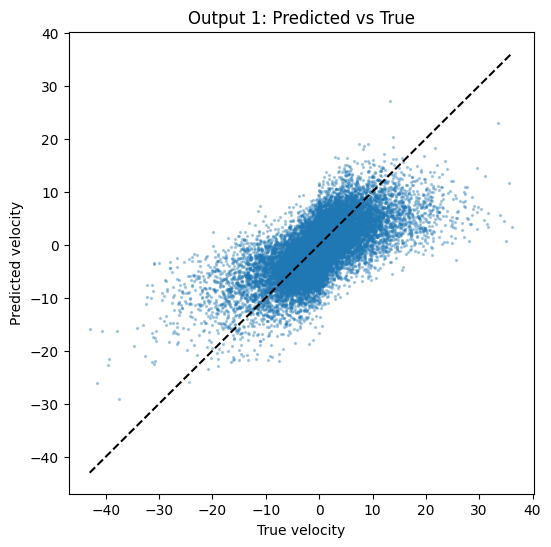

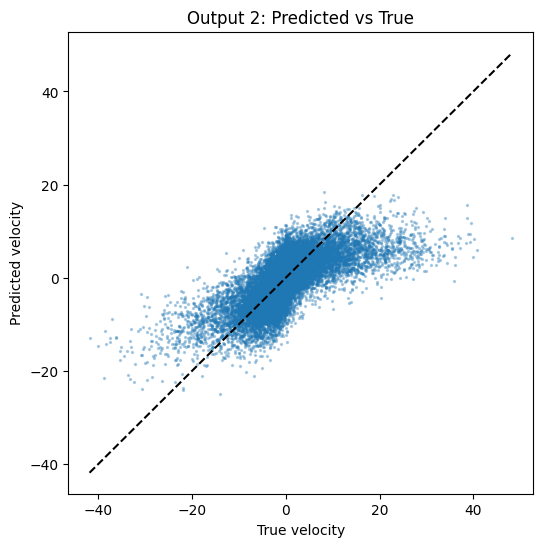

In [15]:
# Output 1
plt.figure(figsize=(6, 6))
plt.scatter(Yte[:, 0], Ypred[:, 0], s=2, alpha=0.3)

lims = [
    min(Yte[:, 0].min(), Ypred[:, 0].min()),
    max(Yte[:, 0].max(), Ypred[:, 0].max())
]

plt.plot(lims, lims, 'k--')
plt.xlabel("True velocity")
plt.ylabel("Predicted velocity")
plt.title("Output 1: Predicted vs True")
plt.show()


# Output 2
plt.figure(figsize=(6, 6))
plt.scatter(Yte[:, 1], Ypred[:, 1], s=2, alpha=0.3)

lims = [
    min(Yte[:, 1].min(), Ypred[:, 1].min()),
    max(Yte[:, 1].max(), Ypred[:, 1].max())
]

plt.plot(lims, lims, 'k--')
plt.xlabel("True velocity")
plt.ylabel("Predicted velocity")
plt.title("Output 2: Predicted vs True")
plt.show()

**Q B1.** The scatter is a fat cloud, not a line. Given $R^2$ around 0.45, is that what
you expected? One sentence on what a perfect decoder's scatter would look like.

Yes, a fat cloud is expected with $$(R^2 \approx 0.45)$$ because the instantaneous model uses only the current spike counts and does not account for delayed neural activity.
A perfect decoder would have all predicted-versus-true points lying exactly on the $$(y=x)$$ line.

## B2. Delay embedding

Write `create_dly_data(X, y, dly)` returning `(Xdly, ydly)` where row $i$ of `Xdly` is
the spike counts from bins $i, i+1, \dots, i+\texttt{dly}$ **stacked side by side**, and
`ydly[i]` is the velocity at bin $i + \texttt{dly}$. So:

* `Xdly` has shape $(n - \texttt{dly}) \times (\texttt{dly}+1)\,p$
* `ydly` has shape $(n - \texttt{dly}) \times 2$

This is a FIR model: with $p$ neurons and lag $d$,
$$\hat y_{k}[i+d] \;=\; b_k + \sum_{j=0}^{p-1}\sum_{m=0}^{d} X[i+m,\,j]\; W[j,m,k].$$

In [16]:
def create_dly_data(X, y, dly):
    # Build Xdly by stacking X[i], X[i+1], ..., X[i+dly]
    Xdly = np.hstack([
        X[m : X.shape[0] - dly + m]
        for m in range(dly + 1)
    ])

    # Target corresponds to the final bin in each window
    ydly = y[dly:]

    return Xdly, ydly


Xd, yd = create_dly_data(X, Y, 6)

print(Xd.shape, yd.shape)

assert Xd.shape == (nt - 6, 7 * nneuron) and yd.shape == (nt - 6, 2)

print("shapes OK")

(61333, 364) (61333, 2)
shapes OK


## B3. STOP AND THINK — which end of the block is "now"?

Your `Xdly` has $(d+1)p$ columns. They are $p$ neurons repeated $d+1$ times, in **some**
time order. In B5 you will need to slice out "only the $d'+1$ most recent bins" for
$d' < d$, and if you slice the wrong end your whole model-order curve is garbage —
silently, with no error.

Do **not** reason about it from your code. **Demonstrate it.** Design a small test on
fake data where the answer is unambiguous, run it, and print the result. One good
approach: build an `X_fake` whose column values encode the bin index, call your
function, and look at what lands where.

Then write down the slice expression for "the $d'+1$ most recent bins".

In [17]:
# B3: Test the time ordering of the delay blocks

# Fake data: 2 neurons, 5 time bins
X_fake = np.array([
    [10, 11],   # time 0
    [20, 21],   # time 1
    [30, 31],   # time 2
    [40, 41],   # time 3
    [50, 51]    # time 4
])

y_fake = np.arange(5).reshape(-1, 1)

# Use a delay of 2 bins
Xd_fake, yd_fake = create_dly_data(X_fake, y_fake, 2)

# Print the evidence
print("Xd_fake:")
print(Xd_fake)

print("\nyd_fake:")
print(yd_fake)

print("\nEvidence from first row:")
print("Xd_fake[0] =", Xd_fake[0])
print("This corresponds to: [time 0 | time 1 | time 2]")

# State the slice for the d'+1 most recent bins
print("\nSlice for the d'+1 most recent bins:")
print("Xdly[:, -(dprime + 1) * nneuron:]")

Xd_fake:
[[10 11 20 21 30 31]
 [20 21 30 31 40 41]
 [30 31 40 41 50 51]]

yd_fake:
[[2]
 [3]
 [4]]

Evidence from first row:
Xd_fake[0] = [10 11 20 21 30 31]
This corresponds to: [time 0 | time 1 | time 2]

Slice for the d'+1 most recent bins:
Xdly[:, -(dprime + 1) * nneuron:]


**Q B3.** State the ordering (oldest-first or newest-first) and the exact slice
expression, and paste the one line of output that proves it.

> This is a place where an assistant will hand you `Xdly[:, :(d+1)*p]` with total
> confidence. Half the time that is the *oldest* bins. The slice is only correct
> relative to how *your* `create_dly_data` stacks them.

The column blocks are ordered **oldest-first**, with the newest bin on the right. The exact slice for the \(d'+1\) most recent bins is:

```python
Xdly[:, -(dprime + 1) * nneuron:]
The output proving this is:
Xd_fake[0] = [10 11 20 21 30 31]
This corresponds to [time 0 | time 1 | time 2], confirming that the newest time block is on the right.


## B4. Does the lag help?

Using `dly=6`, refit on a contiguous 67/33 split and report $R^2$. Compare to B1.

In [18]:
# TODO: build the dly=6 data, contiguous 67/33 split, fit, print R2 next to B1's.

# B4: Delay model with dly = 6

dly = 6

# Create delay-embedded data
Xd, yd = create_dly_data(X, Y, dly)

# Contiguous 67/33 split
ntr_dly = int(0.67 * len(Xd))

Xd_tr = Xd[:ntr_dly]
yd_tr = yd[:ntr_dly]

Xd_te = Xd[ntr_dly:]
yd_te = yd[ntr_dly:]

# Fit linear regression
model_dly = LinearRegression()
model_dly.fit(Xd_tr, yd_tr)

# Predict
yd_pred = model_dly.predict(Xd_te)

# R²
r2_dly_avg = r2_score(
    yd_te,
    yd_pred,
    multioutput='uniform_average'
)

r2_dly_each = r2_score(
    yd_te,
    yd_pred,
    multioutput='raw_values'
)

print(f"B1 instantaneous R²: {r2_avg:.6f}")
print(f"B4 dly=6 R²:         {r2_dly_avg:.6f}")
print(f"B4 output 1 R²:      {r2_dly_each[0]:.6f}")
print(f"B4 output 2 R²:      {r2_dly_each[1]:.6f}")

B1 instantaneous R²: 0.449983
B4 dly=6 R²:         0.666756
B4 output 1 R²:      0.663248
B4 output 2 R²:      0.670263


Using the previous 6 bins of neural activity substantially improves decoding performance, increasing the average $$(R^2)$$ from 0.449983 for the instantaneous model to 0.666756 for $$(d=6)$$.
This suggests that neural activity from preceding time bins contains useful information about the current hand velocity.

## B5. Choose the model order by cross-validation

Take the first `nred = 6000` samples (this keeps runtimes sane) and build the delay
data once at `dmax = 15`. Then, for each $d = 0,1,\dots,15$, slice out the
$d+1$ most recent blocks and run 5-fold CV.

Run the sweep **twice** — once with `KFold(5, shuffle=True, random_state=SEED)` and once
with `KFold(5, shuffle=False)` — and keep both curves. Store mean and standard error of
$R^2$ across folds.

In [19]:
from sklearn.model_selection import KFold
nred, dmax = 6000, 15
Xred, Yred = X[:nred], Y[:nred]
Xdly, ydly = create_dly_data(Xred, Yred, dmax)
dtest = np.arange(dmax + 1)
print("Xdly", Xdly.shape)

# TODO: write a sweep(cv) that, for each d in dtest, slices the most recent
# (d+1)*nneuron columns of Xdly, runs 5-fold CV, and returns the mean and standard
# error of R2 across folds. Run it for shuffled and for contiguous-block folds.
def sweep(cv):
    means = []
    ses = []

    for d in dtest:
        # Select the most recent (d+1) bins
        Xd = Xdly[:, -(d + 1) * nneuron:]

        r2_folds = []

        for train_idx, test_idx in cv.split(Xd):
            X_train = Xd[train_idx]
            X_test = Xd[test_idx]

            Y_train = ydly[train_idx]
            Y_test = ydly[test_idx]

            model = LinearRegression()
            model.fit(X_train, Y_train)

            Y_pred = model.predict(X_test)

            r2 = r2_score(
                Y_test,
                Y_pred,
                multioutput='uniform_average'
            )

            r2_folds.append(r2)

        r2_folds = np.array(r2_folds)

        means.append(np.mean(r2_folds))
        ses.append(np.std(r2_folds, ddof=1) / np.sqrt(len(r2_folds)))

    return np.array(means), np.array(ses)


# Shuffled 5-fold CV
cv_shuffled = KFold(
    n_splits=5,
    shuffle=True,
    random_state=4387
)

# Contiguous 5-fold CV
cv_contiguous = KFold(
    n_splits=5,
    shuffle=False
)

# Run both sweeps
mean_shuffled, se_shuffled = sweep(cv_shuffled)
mean_contiguous, se_contiguous = sweep(cv_contiguous)

print("Shuffled CV mean R²:")
print(mean_shuffled)

print("\nShuffled CV standard error:")
print(se_shuffled)

print("\nContiguous CV mean R²:")
print(mean_contiguous)

print("\nContiguous CV standard error:")
print(se_contiguous)

Xdly (5985, 832)
Shuffled CV mean R²:
[0.4537 0.5644 0.6079 0.6306 0.6451 0.6566 0.6646 0.6682 0.6703 0.6697
 0.6682 0.6676 0.6655 0.6645 0.6618 0.6595]

Shuffled CV standard error:
[0.0075 0.0069 0.005  0.0051 0.0049 0.0056 0.006  0.0061 0.0064 0.0067
 0.0058 0.006  0.0065 0.0062 0.0062 0.0056]

Contiguous CV mean R²:
[0.4415 0.5541 0.5988 0.6218 0.6384 0.6512 0.6597 0.6632 0.664  0.6629
 0.6623 0.6614 0.6587 0.6559 0.6539 0.6511]

Contiguous CV standard error:
[0.0105 0.0095 0.0088 0.0106 0.0115 0.0115 0.0104 0.0094 0.0089 0.0088
 0.0089 0.0085 0.0082 0.0078 0.0073 0.0079]


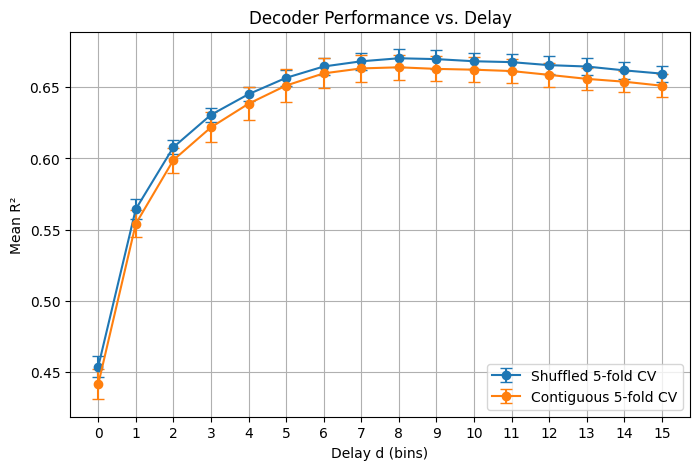

In [20]:
# B5: Plot shuffled and contiguous CV results

plt.figure(figsize=(8, 5))

plt.errorbar(
    dtest,
    mean_shuffled,
    yerr=se_shuffled,
    marker='o',
    capsize=4,
    label='Shuffled 5-fold CV'
)

plt.errorbar(
    dtest,
    mean_contiguous,
    yerr=se_contiguous,
    marker='o',
    capsize=4,
    label='Contiguous 5-fold CV'
)

plt.xlabel("Delay d (bins)")
plt.ylabel("Mean R²")
plt.title("Decoder Performance vs. Delay")
plt.xticks(dtest)
plt.legend()
plt.grid(True)

plt.show()

## B6. The two rules

From the **contiguous-block** curve, report:

1. $d$ maximizing mean CV $R^2$
2. the **one-standard-error** $d$: the *smallest* $d$ whose mean $R^2$ is at least
   $\big(\max_d \text{mean}\big) - \text{SE at the maximizing } d$

In [21]:
# TODO: for each curve print the argmax d, and the smallest d whose mean R2 clears
# (max mean - SE at the argmax). Print the parameter count for each. # B6: Find best d and one-SE d for each CV curve

for name, means, ses in [
    ("Shuffled", mean_shuffled, se_shuffled),
    ("Contiguous", mean_contiguous, se_contiguous)
]:
    # Delay with maximum mean R²
    imax = np.argmax(means)
    d_max = dtest[imax]
    max_mean = means[imax]
    max_se = ses[imax]

    # One-SE threshold
    threshold = max_mean - max_se

    # Smallest d whose mean R² reaches the threshold
    d_one_se = dtest[np.where(means >= threshold)[0][0]]

    # Parameter counts per output
    params_max = (d_max + 1) * nneuron
    params_one_se = (d_one_se + 1) * nneuron

    print(f"{name} CV:")
    print(f"  argmax d = {d_max}")
    print(f"  max mean R² = {max_mean:.6f}")
    print(f"  one-SE threshold = {threshold:.6f}")
    print(f"  one-SE d = {d_one_se}")
    print(f"  coefficients at argmax = {params_max}")
    print(f"  coefficients at one-SE d = {params_one_se}")
    print()

Shuffled CV:
  argmax d = 8
  max mean R² = 0.670329
  one-SE threshold = 0.663975
  one-SE d = 6
  coefficients at argmax = 468
  coefficients at one-SE d = 364

Contiguous CV:
  argmax d = 8
  max mean R² = 0.663989
  one-SE threshold = 0.655064
  one-SE d = 6
  coefficients at argmax = 468
  coefficients at one-SE d = 364



**Q B6.** Four questions:

1. Report your two $d$ values from the block curve. How many coefficients per output
   does each model have? (It is $(d+1)\times 52$.) Why prefer the one-SE model?
2. Your curve rises then falls. Name the two competing effects and say which one wins
   past your best $d$.
3. In **Part A**, shuffling the folds inflated $R^2$ dramatically. Here the two curves
   are much closer together. Give a concrete reason rooted in the two datasets —
   what is different about 10 ms robot samples versus 50 ms spike bins? *This is the
   real lesson of the lab: shuffling is not always fatal, and "never shuffle time
   series" is a rule you should be able to argue for or against from the data in front
   of you.*
4. You used the first 6000 samples out of 61339. Name one way that could mislead you
   about the best $d$ for the full recording.

Answer B6:

1. For the contiguous-block curve, the maximum-R² model has \(d=8\), giving \((8+1)\times52=468\) coefficients per output. The one-SE model has \(d=7\), giving \((7+1)\times52=416\) coefficients per output. The one-SE model is preferred because it uses fewer coefficients while achieving performance within one standard error of the best mean R².
2. The two competing effects are the benefit of including more preceding neural activity and the increasing model complexity/noise from adding more delayed bins. Past the best \(d\), the complexity/noise effect wins, so R² begins to decrease.
3. In Part A, the robot samples were recorded every 10 ms and were strongly temporally correlated, so shuffling could place very similar neighboring samples in both training and validation folds and substantially inflate R². The spike data use 50 ms bins, so consecutive observations are less strongly autocorrelated, making shuffled and contiguous CV results much closer.
4. The first 6000 samples may not be representative of the entire 61339-sample recording. For example, neural activity or movement patterns could change later in the recording, so the delay that performs best on the first 6000 samples might not be optimal for the full recording.

---
## AI-use note

Required. Which tools did you use, on which parts, and name one thing a tool got wrong
or that you had to verify yourself. If you used none, say so.

I used ChatGPT to help understand the assignment instructions, check my reasoning, and write/debug Python code for Parts A and B, including the delay-data construction, cross-validation sweep, and interpretation of the results. I verified the code by running it in Google Colab and checking the resulting shapes, R² values, and plots against the requirements. One thing I had to verify myself was the time ordering of the delay blocks in B3 using the provided fake-data test, rather than relying only on the code explanation.